In [1]:
"""
Patrones Binarios Locales (LBP) para el Análisis de Texturas

Objetivo
Presentar los Patrones Binarios Locales (LBP) como un descriptor de textura clásico para el análisis de imágenes.

Importancia
En el notebook anterior, exploramé descriptores de textura simples como la intensidad media, la desviación estándar, la entropía y la varianza local. Estas características son útiles, pero solo capturan información estadística general.

LBP proporciona una forma más estructurada de describir la textura local comparando cada píxel con su vecindario.
"""

'\nPatrones Binarios Locales (LBP) para el Análisis de Texturas\n\nObjetivo\nPresentar los Patrones Binarios Locales (LBP) como un descriptor de textura clásico para el análisis de imágenes.\n\nImportancia\nEn el notebook anterior, exploramé descriptores de textura simples como la intensidad media, la desviación estándar, la entropía y la varianza local. Estas características son útiles, pero solo capturan información estadística general.\n\nLBP proporciona una forma más estructurada de describir la textura local comparando cada píxel con su vecindario.\n'

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from scipy.ndimage import uniform_filter
from skimage import data
from skimage.feature import local_binary_pattern
from skimage.measure import shannon_entropy
from skimage.util import img_as_ubyte

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.decomposition import PCA

In [3]:
np.random.seed(42)
def show_images(images, titles, cmap='gray', figsize=(14, 8), save_path=None):
    n = len(images)
    cols = min(3, n)
    rows = int(np.ceil(n / cols))
    
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = np.array(axes).reshape(-1)
    
    for ax, img, title in zip(axes, images, titles):
        ax.imshow(img, cmap=cmap)
        ax.set_title(title)
        ax.axis('off')
    
    for ax in axes[len(images):]:
        ax.axis('off')
    
    plt.tight_layout()

    if save_path is not None:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()


def extract_random_patches(image, patch_size=32, n_patches=40):
    patches = []
    h, w = image.shape
    
    for _ in range(n_patches):
        i = np.random.randint(0, h - patch_size)
        j = np.random.randint(0, w - patch_size)
        patch = image[i:i+patch_size, j:j+patch_size]
        patches.append(patch)
    
    return patches


def compute_lbp(image, P=8, R=1, method='uniform'):
    return local_binary_pattern(image, P=P, R=R, method=method)


def lbp_histogram(image, P=8, R=1, method='uniform', normalize=True):
    lbp = compute_lbp(image, P=P, R=R, method=method)
    
    if method == 'uniform':
        n_bins = P + 2
    else:
        n_bins = int(lbp.max() + 1)
    
    hist, _ = np.histogram(lbp.ravel(), bins=np.arange(0, n_bins + 1), density=normalize)
    return hist


def local_variance(image, size=7):
    image = image.astype(np.float32)
    mean = uniform_filter(image, size=size)
    mean_sq = uniform_filter(image**2, size=size)
    return mean_sq - mean**2

def compute_lbp(image, P=8, R=1, method='uniform'):
    image_uint8 = img_as_ubyte(image)
    return local_binary_pattern(image_uint8, P=P, R=R, method=method)

In [4]:
size = 128

uniform = np.ones((size, size)) * 0.5
noise = np.random.rand(size, size)

x = np.arange(size)
y = np.arange(size)
xx, yy = np.meshgrid(x, y)

stripes = ((xx // 8) % 2).astype(float)
checkerboard = (((xx // 8) + (yy // 8)) % 2).astype(float)

smoothed_noise = uniform_filter(np.random.rand(size, size), size=9)

granular = uniform_filter(np.random.rand(size, size), size=3) + 0.3 * np.random.rand(size, size)
granular = (granular - granular.min()) / (granular.max() - granular.min())

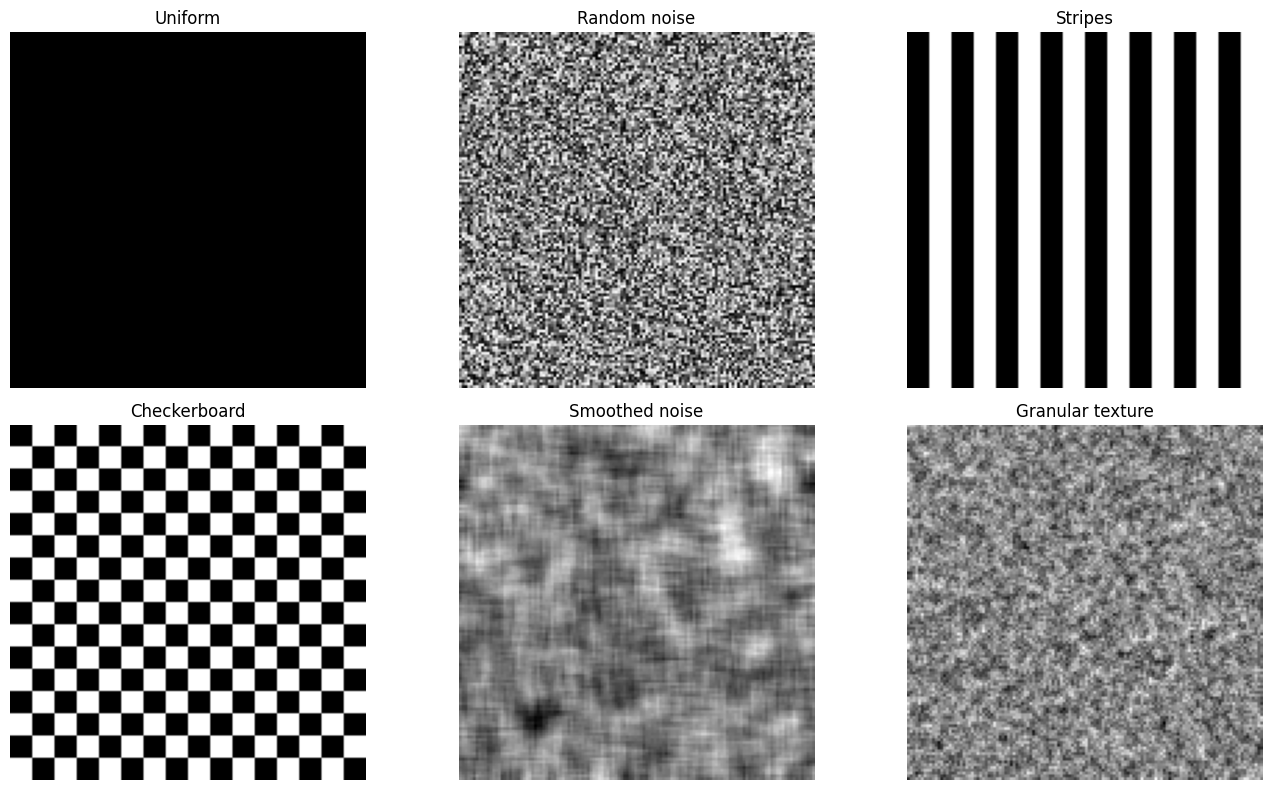

In [5]:
images = [uniform, noise, stripes, checkerboard, smoothed_noise, granular]
titles = [
    "Uniform",
    "Random noise",
    "Stripes",
    "Checkerboard",
    "Smoothed noise",
    "Granular texture"
]

show_images(
    images,
    titles,
    figsize=(14, 8),
    save_path="../figures/figures_texture/lbp_input_textures.png"
)

In [6]:
"""
LBP compara el píxel central con sus vecinos.

Para cada vecino:
- Se asigna 1 si el vecino es mayor o igual que el central.
- Se asigna 0 en caso contrario.

Esto genera un código binario alrededor de cada píxel.

Este código binario se convierte en un número, creando una imagen de patrones de textura locales.
"""

'\nLBP compara el píxel central con sus vecinos.\n\nPara cada vecino:\n- Se asigna 1 si el vecino es mayor o igual que el central.\n- Se asigna 0 en caso contrario.\n\nEsto genera un código binario alrededor de cada píxel.\n\nEste código binario se convierte en un número, creando una imagen de patrones de textura locales.\n'

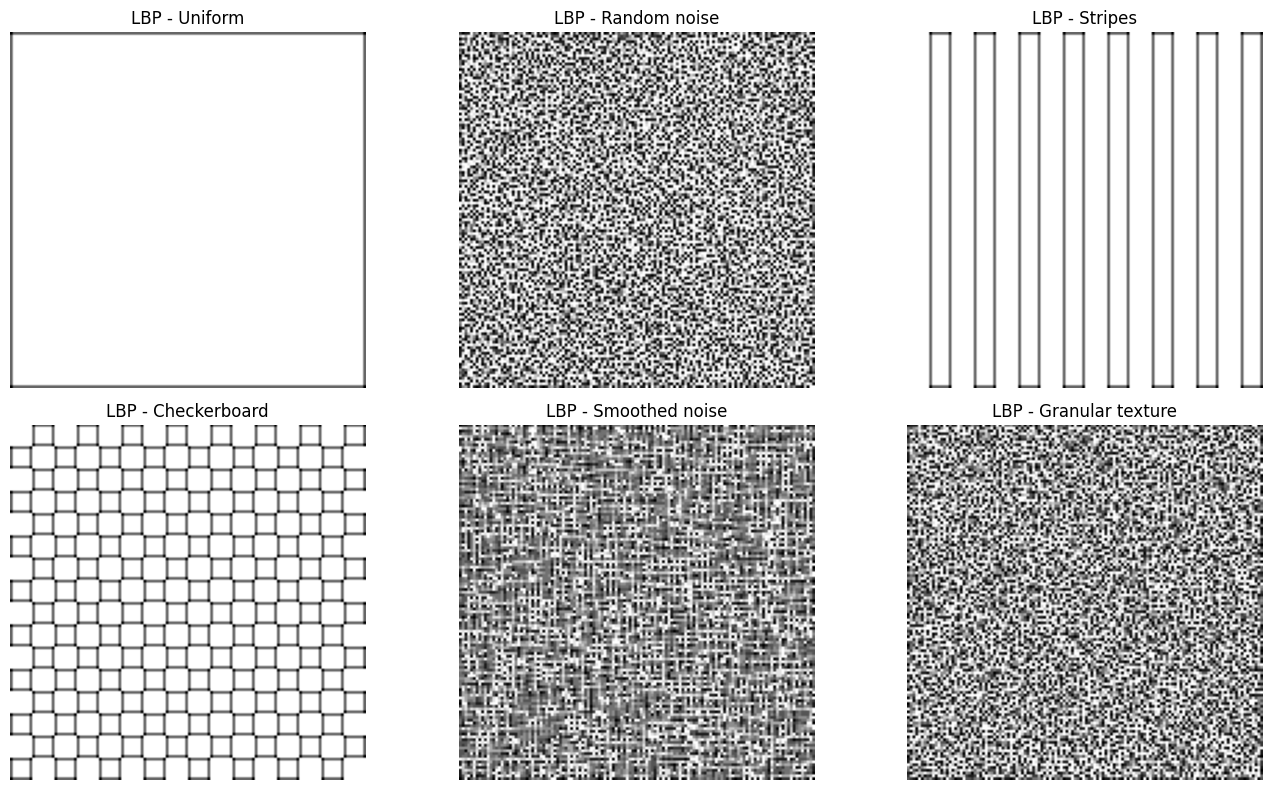

In [7]:
P = 8
R = 1
method = 'uniform'

lbp_maps = [compute_lbp(img, P=P, R=R, method=method) for img in images]
lbp_titles = [f"LBP - {title}" for title in titles]

show_images(
    lbp_maps,
    lbp_titles,
    figsize=(14, 8),
    save_path="../figures/figures_texture/lbp_maps.png"
)

In [8]:
"""
En una imagen uniforme, todos los vecindarios locales son idénticos, por lo que el código LBP es prácticamente constante en toda la imagen.

En patrones de rayas y tablero de ajedrez, el LBP se mantiene estable dentro de las regiones homogéneas, pero cambia drásticamente en los límites, donde los píxeles vecinos difieren del píxel central.

Por esta razón, los mapas LBP suelen resaltar las transiciones y las estructuras locales repetidas, aunque el LBP no sea un detector de bordes clásico.
"""

'\nEn una imagen uniforme, todos los vecindarios locales son idénticos, por lo que el código LBP es prácticamente constante en toda la imagen.\n\nEn patrones de rayas y tablero de ajedrez, el LBP se mantiene estable dentro de las regiones homogéneas, pero cambia drásticamente en los límites, donde los píxeles vecinos difieren del píxel central.\n\nPor esta razón, los mapas LBP suelen resaltar las transiciones y las estructuras locales repetidas, aunque el LBP no sea un detector de bordes clásico.\n'

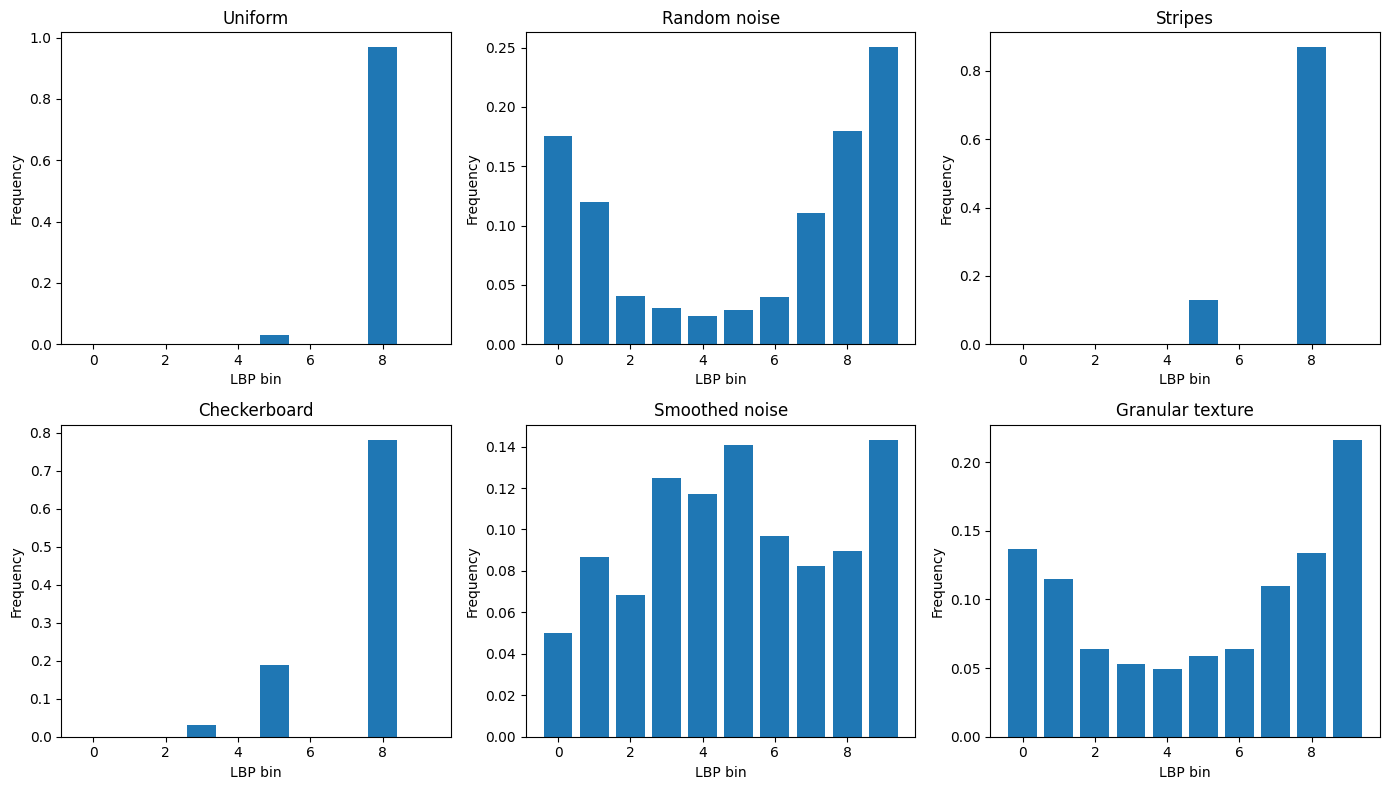

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()

for ax, img, title in zip(axes, images, titles):
    hist = lbp_histogram(img, P=P, R=R, method=method, normalize=True)
    ax.bar(np.arange(len(hist)), hist)
    ax.set_title(title)
    ax.set_xlabel("LBP bin")
    ax.set_ylabel("Frequency")

plt.tight_layout()
os.makedirs("../figures/figures_texture", exist_ok=True)
plt.savefig("../figures/figures_texture/lbp_histograms.png", dpi=300, bbox_inches="tight")
plt.show()

In [11]:
"""
Comparación de histogramas

Las diferentes texturas generan distintos histogramas LBP.

Esto es importante porque nos permite transformar una imagen en un vector de características numéricas que puede utilizarse para la clasificación.
"""

lbp_feature_table = []

for img, title in zip(images, titles):
    hist = lbp_histogram(img, P=P, R=R, method=method, normalize=True)
    row = {"texture": title}
    for i, value in enumerate(hist):
        row[f"bin_{i}"] = value
    lbp_feature_table.append(row)

df_lbp = pd.DataFrame(lbp_feature_table)
df_lbp.head()

,texture,bin_0,bin_1,bin_2,bin_3,bin_4,bin_5,bin_6,bin_7,bin_8,bin_9
0,Uniform,0.000000,0.000000,0.000000,0.000244,0.000000,0.030762,0.000000,0.000000,0.968994,0.000000
1,Random noise,0.175842,0.119934,0.041016,0.030457,0.023926,0.028992,0.039429,0.110657,0.179443,0.250305
2,Stripes,0.000000,0.000000,0.000000,0.001953,0.000000,0.128906,0.000000,0.000000,0.869141,0.000000
3,Checkerboard,0.000000,0.000000,0.000000,0.031250,0.000000,0.187500,0.000000,0.000000,0.781250,0.000000
4,Smoothed noise,0.049866,0.086792,0.068542,0.124695,0.117249,0.140686,0.096863,0.082336,0.089661,0.143311


In [12]:
texture_dict = {
    0: ("Uniform", uniform),
    1: ("Random noise", noise),
    2: ("Stripes", stripes),
    3: ("Checkerboard", checkerboard),
    4: ("Smoothed noise", smoothed_noise),
    5: ("Granular texture", granular),
}

X = []
y = []

for label, (name, img) in texture_dict.items():
    patches = extract_random_patches(img, patch_size=32, n_patches=60)
    for patch in patches:
        hist = lbp_histogram(patch, P=P, R=R, method=method, normalize=True)
        X.append(hist)
        y.append(label)

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (360, 10)
y shape: (360,)


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

clf = RandomForestClassifier(n_estimators=200, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

In [14]:
label_names = [texture_dict[i][0] for i in sorted(texture_dict.keys())]

print(classification_report(y_test, y_pred, target_names=label_names))

                  precision    recall  f1-score   support

         Uniform       1.00      1.00      1.00        15
    Random noise       1.00      1.00      1.00        15
         Stripes       1.00      1.00      1.00        15
    Checkerboard       1.00      1.00      1.00        15
  Smoothed noise       1.00      1.00      1.00        15
Granular texture       1.00      1.00      1.00        15

        accuracy                           1.00        90
       macro avg       1.00      1.00      1.00        90
    weighted avg       1.00      1.00      1.00        90



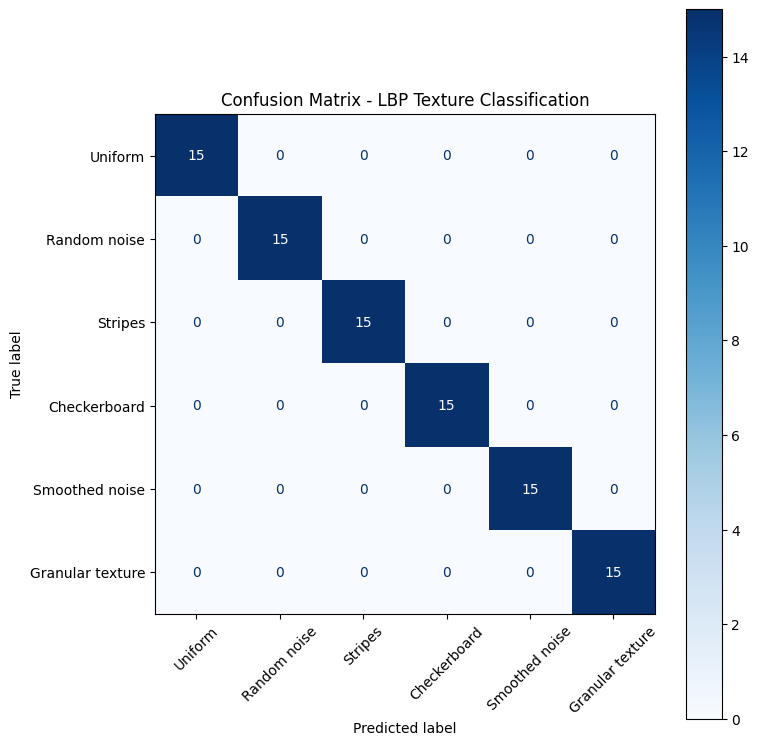

In [15]:
fig, ax = plt.subplots(figsize=(8, 8))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=label_names, cmap='Blues', ax=ax
)
plt.title("Confusion Matrix - LBP Texture Classification")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../figures/figures_texture/lbp_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

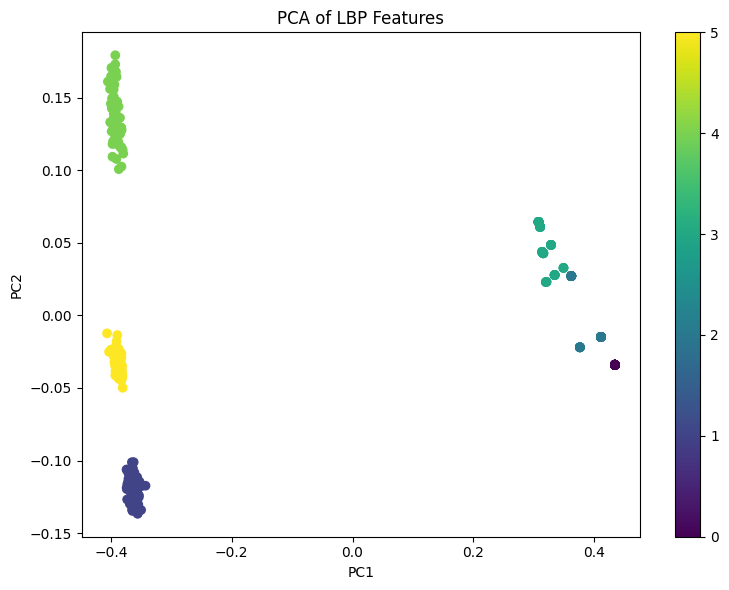

In [17]:
"""
Visualización del espacio de características con PCA
Para comprender mejor cómo LBP separa las clases de textura, proyectamos los vectores de características en dos dimensiones utilizando PCA.
"""
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of LBP Features")
plt.colorbar(scatter, ticks=range(len(label_names)))
plt.tight_layout()
plt.savefig("../figures/figures_texture/lbp_pca.png", dpi=300, bbox_inches="tight")
plt.show()

In [18]:
"""
Los patrones binarios locales (LBP) proporcionan una representación compacta e interpretable de la textura local.
En comparación con las estadísticas globales básicas, LBP captura una estructura local más rica y permite la clasificación de texturas mediante modelos estándar de aprendizaje automático.
Esto convierte a LBP en una valiosa herramienta clásica de visión artificial y en un sólido puente hacia flujos de trabajo de análisis de imágenes científicas más avanzados.
"""

'\nLos patrones binarios locales (LBP) proporcionan una representación compacta e interpretable de la textura local.\nEn comparación con las estadísticas globales básicas, LBP captura una estructura local más rica y permite la clasificación de texturas mediante modelos estándar de aprendizaje automático.\nEsto convierte a LBP en una valiosa herramienta clásica de visión artificial y en un sólido puente hacia flujos de trabajo de análisis de imágenes científicas más avanzados.\n'